In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Eksik Veri Kontrolü
print("Missing values:")
print(df.isnull().sum())


# 3. Zaman Serisi Görselleştirme
#plt.figure(figsize=(12, 6))
#plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
#plt.xlabel("Time")
#plt.ylabel("Value")
#plt.title("Time Series Plot of 0_x")
#plt.legend()
#plt.grid(True)
#plt.show()

Missing values:
time    0
0_x     0
dtype: int64


In [15]:
# 4. ADF Durağanlık Testi
# adf_test = adfuller(df['0_x'])
# print("ADF Statistic:", adf_test[0])
# print("p-value:", adf_test[1])
# print("Critical Values:", adf_test[4])

# Durağan olup olmadığını kontrol etme
# if adf_test[1] < 0.05:
    # print("Sonuç: Seri durağandır (Stationary)")
# else:
    # print("Sonuç: Seri durağan değildir (Non-Stationary)")

In [17]:
# 5. ACF ve PACF Grafikleri
# fig, ax = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(df['0_x'].dropna(), ax=ax[0], lags=20)
# ax[0].set_title("Autocorrelation Function (ACF)")
# plot_pacf(df['0_x'].dropna(), ax=ax[1], lags=20)
# ax[1].set_title("Partial Autocorrelation Function (PACF)")
# plt.tight_layout()
# plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.7746503594867
Gerçek: 630, Tahmin: 630.5768173989203
Gerçek: 628, Tahmin: 629.5125164755352
Gerçek: 627, Tahmin: 627.1365999243069
Gerçek: 627, Tahmin: 626.3681882617523
Gerçek: 627, Tahmin: 626.7977631367712
Gerçek: 627, Tahmin: 626.9353149850792
Gerçek: 626, Tahmin: 626.9792769654011
Gerçek: 626, Tahmin: 625.6411207473532
Gerçek: 625, Tahmin: 625.8846501494884
Gerçek: 624, Tahmin: 624.610954482818
Gerçek: 624, Tahmin: 623.5218777590059
Gerçek: 623, Tahmin: 623.8460814169863
Gerçek: 623, Tahmin: 622.5981378569182
Gerçek: 622, Tahmin: 622.8698978904171
Gerçek: 622, Tahmin: 621.6063240312827
Gerçek: 622, Tahmin: 621.8719647728899
Gerçek: 622, Tahmin: 621.9583637229568
Gerçek: 620, Tahmin: 621.9864560107067
Gerçek: 620, Tahmin: 619.2946085581059
Gerçek: 619, Tahmin: 619.7698415015439
Gerçek: 620, Tahmin: 618.5751201216926
Gerçek: 620, Tahmin: 620.2081367605033
Gerçek: 620, Tahmin: 620.0684158077172
Gerçek: 620, Tahmin: 6

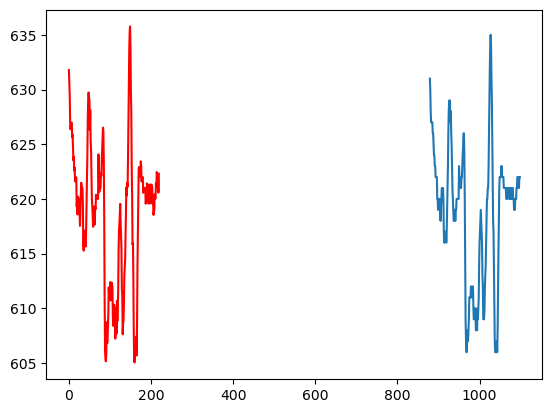

In [13]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(history, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.5629447964526
Gerçek: 630, Tahmin: 630.1417267126174
Gerçek: 628, Tahmin: 628.9379563531091
Gerçek: 627, Tahmin: 626.9008618624076
Gerçek: 627, Tahmin: 625.9958777061712
Gerçek: 627, Tahmin: 626.5186548191521
Gerçek: 627, Tahmin: 626.9761302746414
Gerçek: 626, Tahmin: 626.9568050866504
Gerçek: 626, Tahmin: 625.5842258709698
Gerçek: 625, Tahmin: 625.634110339393
Gerçek: 624, Tahmin: 624.5557883304426
Gerçek: 624, Tahmin: 623.5056824834196
Gerçek: 623, Tahmin: 623.646083588485
Gerçek: 623, Tahmin: 622.743640792607
Gerçek: 622, Tahmin: 622.8679306503665
Gerçek: 622, Tahmin: 621.688304924866
Gerçek: 622, Tahmin: 621.9069410342634
Gerçek: 622, Tahmin: 622.0011748221549
Gerçek: 620, Tahmin: 622.1773778050256
Gerçek: 620, Tahmin: 619.534046376737
Gerçek: 619, Tahmin: 619.6160465094162
Gerçek: 620, Tahmin: 618.7349905989092
Gerçek: 620, Tahmin: 620.3787633567408
Gerçek: 620, Tahmin: 620.3571650575144
Gerçek: 620, Tahmin: 620.3

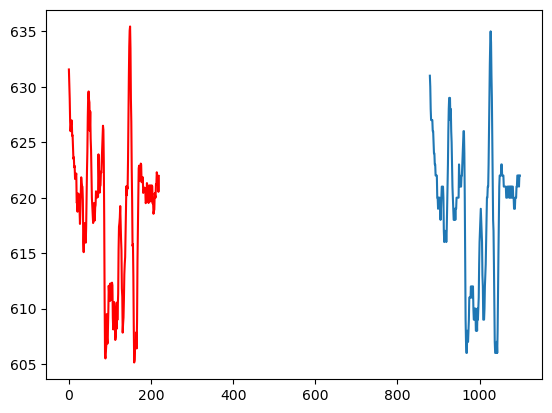

In [17]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(history, order=(5, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.5156917656149
Gerçek: 630, Tahmin: 630.1948444529414
Gerçek: 628, Tahmin: 628.9291985947319
Gerçek: 627, Tahmin: 626.8043506994859
Gerçek: 627, Tahmin: 626.0522356413907
Gerçek: 627, Tahmin: 626.5284937433829
Gerçek: 627, Tahmin: 626.905909596481
Gerçek: 626, Tahmin: 626.981021211715
Gerçek: 626, Tahmin: 625.532054541331
Gerçek: 625, Tahmin: 625.5871341457171
Gerçek: 624, Tahmin: 624.6270541040377
Gerçek: 624, Tahmin: 623.566672604642
Gerçek: 623, Tahmin: 623.659919345158
Gerçek: 623, Tahmin: 622.7194481799316
Gerçek: 622, Tahmin: 622.8607105548647
Gerçek: 622, Tahmin: 621.7061647864605
Gerçek: 622, Tahmin: 621.8501957037747
Gerçek: 622, Tahmin: 622.0292236447804
Gerçek: 620, Tahmin: 622.2039800637297
Gerçek: 620, Tahmin: 619.5205642068867
Gerçek: 619, Tahmin: 619.6075637979695
Gerçek: 620, Tahmin: 618.7146441951348
Gerçek: 620, Tahmin: 620.4484086813185
Gerçek: 620, Tahmin: 620.3965176207157
Gerçek: 620, Tahmin: 620.2

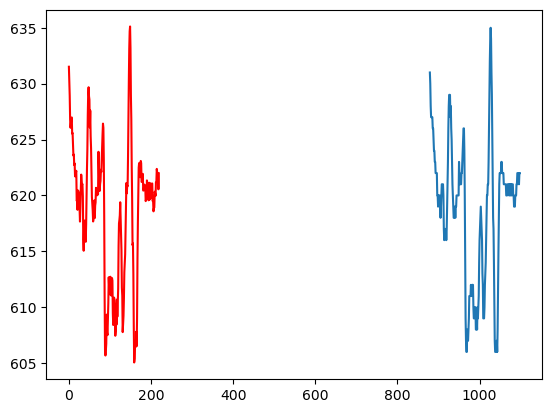

In [19]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(history, order=(10, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.5982623736157
Gerçek: 630, Tahmin: 630.2121331983269
Gerçek: 628, Tahmin: 629.0136375750379
Gerçek: 627, Tahmin: 626.9833987080408
Gerçek: 627, Tahmin: 626.3075414783754
Gerçek: 627, Tahmin: 626.7153771966927
Gerçek: 627, Tahmin: 627.1300064682729
Gerçek: 626, Tahmin: 627.1039006985749
Gerçek: 626, Tahmin: 625.5562562368726
Gerçek: 625, Tahmin: 625.6785444694809
Gerçek: 624, Tahmin: 624.7575923497564
Gerçek: 624, Tahmin: 623.6897966494879
Gerçek: 623, Tahmin: 623.7711714965958
Gerçek: 623, Tahmin: 622.879531820826
Gerçek: 622, Tahmin: 623.0577686110231
Gerçek: 622, Tahmin: 621.8569518453407
Gerçek: 622, Tahmin: 622.1116691995064
Gerçek: 622, Tahmin: 622.3105200531171
Gerçek: 620, Tahmin: 622.434549548763
Gerçek: 620, Tahmin: 619.6965046257659
Gerçek: 619, Tahmin: 619.7009406388127
Gerçek: 620, Tahmin: 618.6659932915902
Gerçek: 620, Tahmin: 620.4577347676034
Gerçek: 620, Tahmin: 620.4351326753217
Gerçek: 620, Tahmin: 62

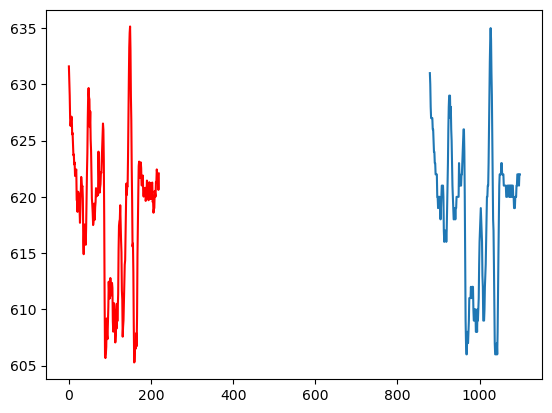

In [21]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][0:train_size], df['0_x'][train_size:len(df)]
history = [x for x in train]

# walk-forward validation
predictions = list()
for t in range(len(test)):
    model = SARIMAX(history, order=(20, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA Model
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])


    #print(predictions)
    #print(history)
    #print("----------------------------------------------------------------------------------------------------")


# 12. Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()